# Orange Pose Estimation Pipeline
**SAM3 + DUSt3R on GPU**

Enable GPU first: Runtime > Change runtime type > T4 GPU

## Step 0: Check GPU

In [ ]:
!nvidia-smi
import torch
print('CUDA:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Mon Apr 27 18:03:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 1: Clone Repo + Submodules

In [ ]:
import os
os.chdir('/content')
!git clone --recurse-submodules https://github.com/DanielChvat/Orange-Pose-Estimation.git
os.chdir('/content/Orange-Pose-Estimation')
!ls

fatal: destination path 'Orange-Pose-Estimation' already exists and is not an empty directory.
dust3r	out  raw_videos  sam3  scripts	util  vis


## Step 2: Install DUSt3R

In [ ]:
os.chdir('/content/Orange-Pose-Estimation/dust3r')
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 80.2 MB/s eta 0:00:00


## Step 3: Install SAM3

In [ ]:
os.chdir('/content/Orange-Pose-Estimation/sam3')
!pip install -e . -q
!pip install --upgrade setuptools -q
print('SAM3 installed!')

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.4 MB/s eta 0:00:00
  Building editable for sam3 (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 r

## Step 4: Download DUSt3R Weights (~2GB)

In [ ]:
os.chdir('/content/Orange-Pose-Estimation')
!mkdir -p dust3r/checkpoints
weights_path = 'dust3r/checkpoints/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth'
if not os.path.exists(weights_path):
    print('Downloading weights...')
    !wget -q --show-progress -O {weights_path} https://download.europe.naverlabs.com/ComputerVision/DUSt3R/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
    print('Done!')
else:
    print('Already downloaded!')

dust3r/checkpoints/ 100%[===================>]   2.13G  22.5MB/s    in 95s     
Done!


## Step 5: Upload Your Video

In [ ]:
from google.colab import files
!mkdir -p /content/Orange-Pose-Estimation/raw_videos
print('Upload your orange video...')
uploaded = files.upload()
video_filename = list(uploaded.keys())[0]
video_path = '/content/Orange-Pose-Estimation/raw_videos/' + video_filename
import shutil
shutil.move(video_filename, video_path)
print('Video saved to:', video_path)

Upload your orange video...


Saving 20260210_095011 (1).mp4 to 20260210_095011 (1).mp4
Video saved to: /content/Orange-Pose-Estimation/raw_videos/20260210_095011 (1).mp4


## Step 6: Configure Parameters

In [ ]:
# ---- EDIT THESE ----
TEXT_PROMPT   = 'orange fruit'
FPS           = 2.0
THRESHOLD     = 0.3
NITER         = 300
SCENEGRAPH    = 'swin'
AS_POINTCLOUD = True
# ---------------------

FRAME_DIR = '/content/Orange-Pose-Estimation/out/frames'
MASK_DIR  = '/content/Orange-Pose-Estimation/out/masks'
OUT_DIR   = '/content/Orange-Pose-Estimation/out'
WEIGHTS   = '/content/Orange-Pose-Estimation/dust3r/checkpoints/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth'
os.makedirs(FRAME_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
print('Config ready!')

Config ready!


In [ ]:
# Fix pkg_resources / Python 3.12 incompatibility
!pip install -q --upgrade setuptools pip
!pip install -q "setuptools<71"
import importlib, sys
# Remove stale pkg_resources from cache
for mod in list(sys.modules.keys()):
    if "pkg_resources" in mod or "setuptools" in mod:
        del sys.modules[mod]
print("pkg_resources fix applied!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pkg_resources fix applied!


## Step 7: Extract Frames + Run SAM3 Segmentation

In [ ]:
os.chdir('/content/Orange-Pose-Estimation/scripts')
!python get_masks.py \
    --video_path "$video_path" \
    --text_prompt "$TEXT_PROMPT" \
    --frame-dir "$FRAME_DIR" \
    --mask-dir "$MASK_DIR" \
    --fps $FPS \
    --threshold $THRESHOLD

/content/Orange-Pose-Estimation/sam3/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
config.json: 25.8kB [00:00, 56.4MB/s]
sam3.pt: 100% 3.45G/3.45G [01:21<00:00, 42.2MB/s]
Extracting frames: 100% 609/609 [00:03<00:00, 173.89frame/s]
[INFO] Extracted 41 frames
Running SAM:   0% 0/41 [00:00<?, ?frame/s]/content/Orange-Pose-Estimation/scripts/get_masks.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast():
Running SAM: 100% 41/41 [00:47<00:00,  1.1

## Step 7b: Preview Frame + Mask

Frames: 41, Masks: 41


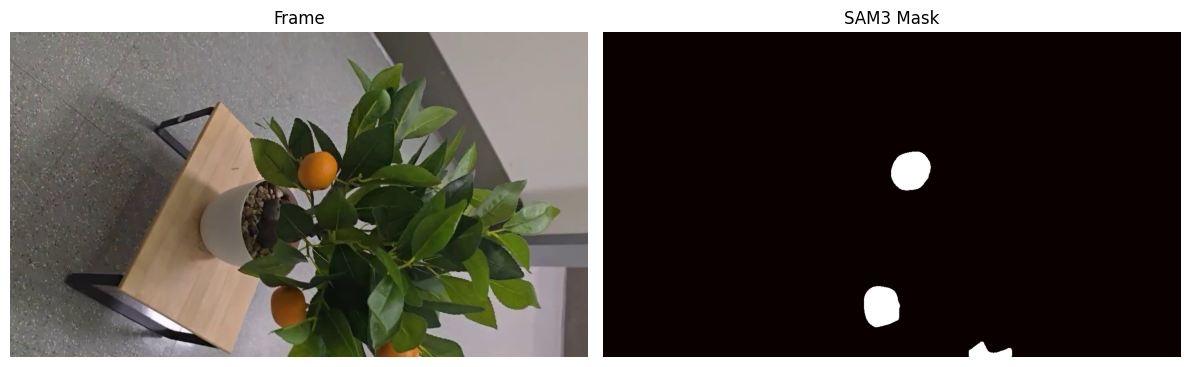

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

frame_files = sorted(os.listdir(FRAME_DIR))
mask_files  = sorted(os.listdir(MASK_DIR))
print(f'Frames: {len(frame_files)}, Masks: {len(mask_files)}')

if frame_files and mask_files:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    img = Image.open(os.path.join(FRAME_DIR, frame_files[0]))
    axes[0].imshow(img); axes[0].set_title('Frame'); axes[0].axis('off')
    mask_data = np.load(os.path.join(MASK_DIR, mask_files[0]))
    mask = mask_data['mask'].squeeze()  # fix: remove the extra dimension
    axes[1].imshow(mask, cmap='hot'); axes[1].set_title('SAM3 Mask'); axes[1].axis('off')
    plt.tight_layout()
    plt.show()

## Step 8: Run DUSt3R 3D Reconstruction

In [ ]:
os.chdir('/content/Orange-Pose-Estimation/scripts')
pc_flag = '--as-pointcloud' if AS_POINTCLOUD else ''
!python generate_pointcloud.py \
    --frame-dir "/content/frames" \
    --out-dir "$OUT_DIR" \
    --weights "$WEIGHTS" \
    --image-size 512 \
    --niter $NITER \
    --scenegraph $SCENEGRAPH \
    $pc_flag

/content/Orange-Pose-Estimation/dust3r/dust3r/cloud_opt/base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
[INFO] Found 41 frames
[INFO] Loading model...
... loading model from /content/Orange-Pose-Estimation/dust3r/checkpoints/DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
instantiating : AsymmetricCroCo3DStereo(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100', patch_embed_cls='PatchEmbedDust3R', img_size=(512, 512), head_type='dpt', output_mode='pts3d', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), landscape_only=False)
<All keys matched successfully>
[INFO] Loading images...
>> Loading a list of 41 images
 - adding /content/frames/frame_0000.jpg with resolution 720x1280 --> 288x512
 - ad

## Step 9: View Results Summary

In [ ]:
import json

poses_path = os.path.join(OUT_DIR, 'camera_poses.json')
with open(poses_path) as f:
    poses = json.load(f)
print(f'Frames reconstructed: {len(poses)}')
print(json.dumps(poses[0], indent=2))

print('\nOutput files:')
for fname in sorted(os.listdir(OUT_DIR)):
    fpath = os.path.join(OUT_DIR, fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f'  {fname}  ({size_mb:.1f} MB)')

Frames reconstructed: 41
{
  "frame_idx": 0,
  "filename": "frame_0000.jpg",
  "tx": -0.14951230585575104,
  "ty": -0.00669896649196744,
  "tz": 0.07352094352245331,
  "qx": 0.10350656998420353,
  "qy": 0.3074408020101659,
  "qz": 0.2858880289025567,
  "qw": 0.9016843007170868,
  "focal": 445.9957275390625
}

Output files:
  README.md  (0.0 MB)
  camera_poses.json  (0.0 MB)
  frame_0000_pts3d.npz  (1.5 MB)
  frame_0001_pts3d.npz  (1.5 MB)
  frame_0002_pts3d.npz  (1.5 MB)
  frame_0003_pts3d.npz  (1.5 MB)
  frame_0004_pts3d.npz  (1.5 MB)
  frame_0005_pts3d.npz  (1.5 MB)
  frame_0006_pts3d.npz  (1.5 MB)
  frame_0007_pts3d.npz  (1.5 MB)
  frame_0008_pts3d.npz  (1.5 MB)
  frame_0009_pts3d.npz  (1.5 MB)
  frame_0010_pts3d.npz  (1.5 MB)
  frame_0011_pts3d.npz  (1.5 MB)
  frame_0012_pts3d.npz  (1.5 MB)
  frame_0013_pts3d.npz  (1.5 MB)
  frame_0014_pts3d.npz  (1.5 MB)
  frame_0015_pts3d.npz  (1.5 MB)
  frame_0016_pts3d.npz  (1.5 MB)
  frame_0017_pts3d.npz  (1.5 MB)
  frame_0018_pts3d.npz  (1.5 

## Step 10: Download Results

In [ ]:
from google.colab import files

# Download the 3D scene (open at gltf-viewer.donmccurdy.com)
scene_glb = os.path.join(OUT_DIR, 'scene.glb')
if os.path.exists(scene_glb):
    files.download(scene_glb)
    print('scene.glb downloaded! View at: https://gltf-viewer.donmccurdy.com')

# Download everything as zip
!zip -r /content/orange_results.zip "$OUT_DIR" "$MASK_DIR"
files.download('/content/orange_results.zip')
print('Full results zip downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

scene.glb downloaded! View at: https://gltf-viewer.donmccurdy.com
  adding: content/Orange-Pose-Estimation/out/ (stored 0%)
  adding: content/Orange-Pose-Estimation/out/frame_0011_pts3d.npz (deflated 0%)
  adding: content/Orange-Pose-Estimation/out/frame_0014_pts3d.npz (deflated 0%)
  adding: content/Orange-Pose-Estimation/out/frame_0039_pts3d.npz (deflated 0%)
  adding: content/Orange-Pose-Estimation/out/frame_0003_pts3d.npz (deflated 0%)
  adding: content/Orange-Pose-Estimation/out/depths/ (stored 0%)
  adding: content/Orange-Pose-Estimation/out/depths/frame_0033_depth.npz (deflated 0%)
  adding: content/Orange-Pose-Estimation/out/depths/frame_0036_depth.npz (deflated 0%)
  adding: content/Orange-Pose-Estimation/out/depths/frame_0007_depth.npz (deflated 0%)
  adding: content/Orange-Pose-Estimation/out/depths/frame_0030_depth.npz (deflated 0%)
  adding: content/Orange-Pose-Estimation/out/depths/frame_0008_depth.npz (deflated 0%)
  adding: content/Orange-Pose-Estimation/out/depths/fram

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Full results zip downloaded!


In [ ]:
!pip install -q --upgrade numpy scipy
import importlib, sys

# Clear stale numpy from session
for mod in list(sys.modules.keys()):
    if 'numpy' in mod or 'scipy' in mod:
        del sys.modules[mod]

print('Done — now go to Runtime > Restart session, then re-run from Step 7b onwards')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam3 0.1.0 requires numpy<2,>=1.26, but you have numpy 2.4.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
Done — now go to Runtime > Restart session, then re-run from Step 7b onwards


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json
import os

# Load camera poses
with open(os.path.join(OUT_DIR, 'camera_poses.json')) as f:
    poses = json.load(f)

# Pick a frame to test (change this index to try others)
TEST_IDX = 0

pose = poses[TEST_IDX]
frame_file = sorted(os.listdir(FRAME_DIR))[TEST_IDX]

# Load the 3D points for this frame
stem = os.path.splitext(frame_file)[0]
pts3d_data = np.load(os.path.join(OUT_DIR, f'{stem}_pts3d.npz'))
pts3d = pts3d_data['pts3d']   # (H, W, 3)
mask  = pts3d_data['mask']    # (H, W) bool

# Load original image
img = np.array(Image.open(os.path.join(FRAME_DIR, frame_file)))

# Build camera-to-world matrix
tx, ty, tz = pose['tx'], pose['ty'], pose['tz']
qx, qy, qz, qw = pose['qx'], pose['qy'], pose['qz'], pose['qw']
focal = pose['focal']

from scipy.spatial.transform import Rotation
R = Rotation.from_quat([qx, qy, qz, qw]).as_matrix()  # (3,3)
t = np.array([tx, ty, tz])                              # (3,)

# World-to-camera: invert c2w
R_inv = R.T
t_inv = -R_inv @ t

# Flatten valid points
H, W = pts3d.shape[:2]
pts_flat = pts3d[mask]         # (N, 3)

# Project: camera coords
pts_cam = (R_inv @ pts_flat.T).T + t_inv   # (N, 3)

# Perspective divide
cx, cy = W / 2, H / 2
x_proj = (pts_cam[:, 0] / pts_cam[:, 2]) * focal + cx
y_proj = (pts_cam[:, 1] / pts_cam[:, 2]) * focal + cy

# Filter points that fall inside the image
in_bounds = (
    (x_proj >= 0) & (x_proj < W) &
    (y_proj >= 0) & (y_proj < H) &
    (pts_cam[:, 2] > 0)
)
x_proj = x_proj[in_bounds]
y_proj = y_proj[in_bounds]

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img)
axes[0].set_title(f'Original: {frame_file}')
axes[0].axis('off')

axes[1].imshow(img)
axes[1].scatter(x_proj, y_proj, s=0.5, c='lime', alpha=0.5)
axes[1].set_title(f'3D pts reprojected (N={in_bounds.sum()})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Total valid pts3d: {mask.sum()}')
print(f'Reprojected in-bounds: {in_bounds.sum()}')
print(f'Focal length: {focal:.1f}px')
print(f'Camera position: ({tx:.3f}, {ty:.3f}, {tz:.3f})')

NameError: name 'OUT_DIR' is not defined

Image aspect: 1.78, pts3d aspect: 0.56
Transposing pts3d to fix orientation...
After transpose: 512x288, aspect: 1.78


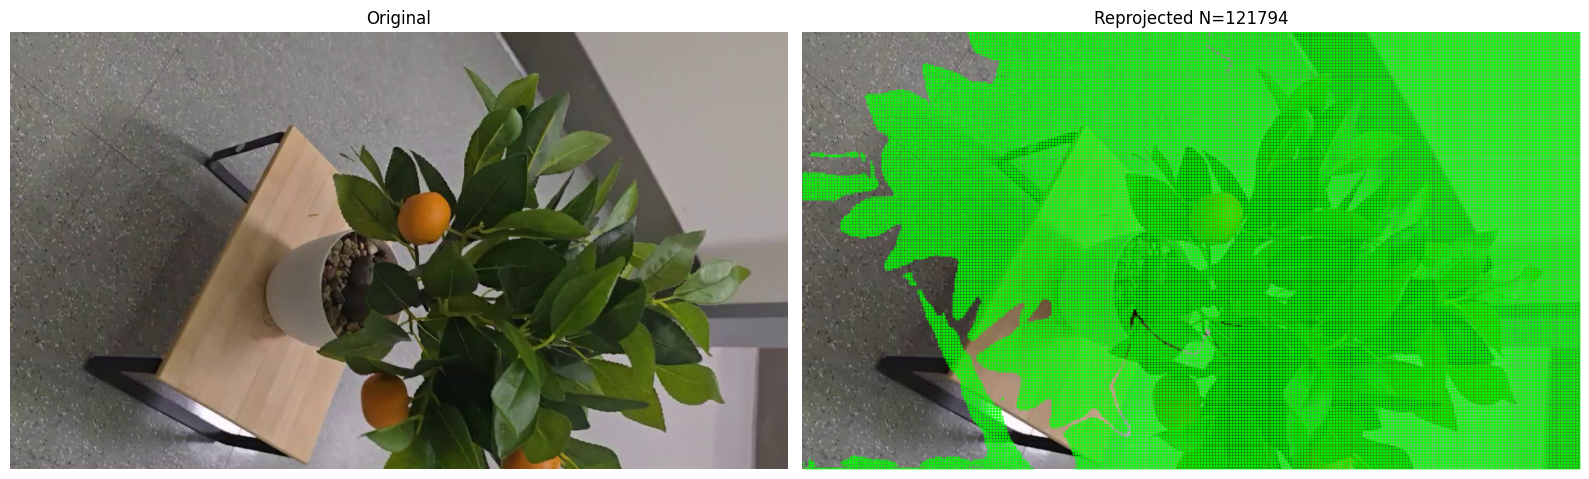

pts3d res after fix: 512x288  scale: x=2.50 y=2.50


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json, os

with open(os.path.join(OUT_DIR, 'camera_poses.json')) as f:
    poses = json.load(f)

TEST_IDX = 0
pose = poses[TEST_IDX]
frame_file = sorted(f for f in os.listdir(FRAME_DIR) if f.endswith('.jpg'))[TEST_IDX]
stem = os.path.splitext(frame_file)[0]

pts3d_data = np.load(os.path.join(OUT_DIR, f'{stem}_pts3d.npz'))
pts3d = pts3d_data['pts3d']   # (512, 288, 3) — stored as H=512, W=288
mask  = pts3d_data['mask']

img = np.array(Image.open(os.path.join(FRAME_DIR, frame_file)))
H_orig, W_orig = img.shape[:2]  # 720, 1280

# pts3d is (H_s, W_s) but DUSt3R may have transposed — check aspect ratio
H_s, W_s = pts3d.shape[:2]  # 512, 288

# Aspect ratios
ar_img  = W_orig / H_orig        # 1280/720 = 1.78 (landscape)
ar_pts  = W_s / H_s              # 288/512 = 0.56 (portrait) ← WRONG

print(f"Image aspect: {ar_img:.2f}, pts3d aspect: {ar_pts:.2f}")

# If aspects don't match, transpose pts3d
if abs(ar_img - ar_pts) > abs(ar_img - H_s/W_s):
    print("Transposing pts3d to fix orientation...")
    pts3d = pts3d.transpose(1, 0, 2)  # (288, 512, 3) → W becomes H
    mask  = mask.transpose(1, 0)
    H_s, W_s = pts3d.shape[:2]
    print(f"After transpose: {W_s}x{H_s}, aspect: {W_s/H_s:.2f}")

focal = pose['focal']
cx_s, cy_s = W_s / 2.0, H_s / 2.0

pts = pts3d[mask]
front = pts[:, 2] > 0
pts_f = pts[front]

x_small = pts_f[:, 0] / pts_f[:, 2] * focal + cx_s
y_small = pts_f[:, 1] / pts_f[:, 2] * focal + cy_s

# Scale to original image
x_orig = x_small * (W_orig / W_s)
y_orig = y_small * (H_orig / H_s)

in_bounds = (x_orig >= 0) & (x_orig < W_orig) & (y_orig >= 0) & (y_orig < H_orig)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img)
axes[1].scatter(x_orig[in_bounds], y_orig[in_bounds], s=0.5, c='lime', alpha=0.5)
axes[1].set_title(f'Reprojected N={in_bounds.sum()}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"pts3d res after fix: {W_s}x{H_s}  scale: x={W_orig/W_s:.2f} y={H_orig/H_s:.2f}")